In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dtale
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "price_value",
    "building_size",
    "rooms_count",
    "construction_year",
    "location_latitude",
    "location_longitude"
]
data = pd.read_csv("Divar.csv", usecols=cols)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   cat2_slug           1000000 non-null  str    
 1   cat3_slug           999999 non-null   str    
 2   city_slug           999998 non-null   str    
 3   neighborhood_slug   437139 non-null   str    
 4   price_value         568346 non-null   float64
 5   building_size       980394 non-null   float64
 6   rooms_count         845899 non-null   str    
 7   construction_year   815828 non-null   str    
 8   location_latitude   655608 non-null   float64
 9   location_longitude  655608 non-null   float64
dtypes: float64(4), str(6)
memory usage: 127.0 MB


In [4]:
cat2_counts = data["cat2_slug"].value_counts()
cat2_counts

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [5]:
cat2_report = (data.groupby("cat2_slug").agg(
    ads_number = ("cat2_slug", "count"),
    has_sale_price = ("price_value", "count"),
    has_building_size = ("building_size", "count"),
    has_arz = ("location_latitude", "count"),
    has_tool = ("location_longitude", "count")
))
cols = cat2_report.columns.drop("ads_number")
cat2_percent = (cat2_report[cols].div(cat2_report["ads_number"], axis=0).mul(100))
cat2_percent

,has_sale_price,has_building_size,has_arz,has_tool
cat2_slug,,,,
commercial-rent,0.044406,99.849805,66.527355,66.527355
commercial-sell,82.671573,99.922802,65.703404,65.703404
real-estate-services,6.236149,0.030923,56.712879,56.712879
residential-rent,0.002170,99.991322,66.587117,66.587117
residential-sell,95.750195,99.994451,65.243204,65.243204
temporary-rent,0.016721,99.969903,65.083771,65.083771


دیتاست شامل آگهی های مختلف مثل فروش و اجاره ست و منطقی نیست همرو با هم وارد کا مینز کنیم چون مثلا قیمت یه ملک فروشی با اجاره ماهانه اصلا قابل مقایسه نیست

با بررسی های بالا هم متوجه شدیم رزیدنتال سِل بیشترین تعداد آگهی رو داره و ویژگی های مهمی مثل قیمت و متراژ هم پوشش خوبی توی این دسته بندی دارن 

In [6]:
cat3_count = data["cat3_slug"].value_counts()
cat3_count

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64

In [7]:
residential_sell = data.loc[data["cat2_slug"] == "residential-sell"].copy()
residential_sell["has_mokhtasat"] = (residential_sell["location_latitude"].notnull() & residential_sell["location_longitude"].notnull())
cat3_report = (residential_sell.groupby("cat3_slug").agg(
    ads_number = ("cat3_slug", "size"),
    has_price = ("price_value", "count"),
    has_building_size = ("building_size", "count"),
    has_rooms = ("rooms_count", "count"),
    has_construction_year = ("construction_year", "count"),
    has_mokhtasat = ("has_mokhtasat", "sum")
))
cols = cat3_report.columns.drop("ads_number")
cat3_percent = (cat3_report[cols].div(cat3_report["ads_number"], axis=0).mul(100))
cat3_percent

,has_price,has_building_size,has_rooms,has_construction_year,has_mokhtasat
cat3_slug,,,,,
apartment-sell,99.998352,99.998352,99.998022,99.998352,67.594640
house-villa-sell,99.995893,99.987680,99.987680,99.987680,61.355367
plot-old,82.231040,99.991765,0.000749,0.000749,63.446133


توی این دسته بندی میریم سمت آپارتمان سل که جزو دسته بندی همون رزیدنتال سل هست چون توی دسته بندی رزیدنتال زمین و ملک هست و مثلا تعداد اتاق برای آپارتمان معیار مهمیه ولی برای زمین خالی هیچ معنایی نداره یا متراژ ساختمان ها 100 و 200 متر هست ولی برای زمین همچین اعدادی به شدت کوچیک بنظر میان

In [8]:
usefull_cols_for_apartment = [
    "city_slug",
    "neighborhood_slug",
    "price_value",
    "building_size",
    "rooms_count",
    "construction_year",
    "location_latitude",
    "location_longitude",
    "has_mokhtasat"
]
apartment_sale = residential_sell.loc[residential_sell["cat3_slug"] == "apartment-sell", usefull_cols_for_apartment].copy()
apartment_sale.head(10)

,city_slug,neighborhood_slug,price_value,building_size,rooms_count,construction_year,location_latitude,location_longitude,has_mokhtasat
1,tehran,gholhak,8.500000e+09,60.0,یک,۱۳۸۴,NaN,NaN,False
4,mashhad,emamreza,5.750000e+09,115.0,دو,۱۴۰۳,NaN,NaN,False
7,tehran,dardasht,8.700000e+09,100.0,دو,۱۳۹۳,35.729832,51.505466,True
8,mahdasht-city,NaN,6.500000e+08,78.0,دو,۱۳۹۶,35.712364,50.794781,True
9,mashhad,faramarzabbasi,3.000000e+09,80.0,دو,۱۳۸۷,NaN,NaN,False
10,pardis-city,NaN,2.600000e+09,87.0,دو,۱۴۰۳,35.778664,51.757549,True
12,mashhad,farhang,1.299000e+10,169.0,سه,۱۴۰۳,36.321831,59.524502,True
25,tehran,kamraniyeh,1.330000e+11,400.0,چهار,۱۴۰۲,NaN,NaN,False
29,arak,NaN,5.700000e+09,114.0,دو,۱۳۹۸,NaN,NaN,False
30,pishva,NaN,9.500000e+08,64.0,یک,۱۴۰۰,35.313835,51.733246,True


In [9]:
base_features = [
    "price_value",
    "building_size",
    "location_latitude",
    "location_longitude"
]
apartment_sale["has_base_features"] = (apartment_sale[base_features].notnull().all(axis=1))

In [10]:
city_report = (apartment_sale.groupby("city_slug").agg(
    ads_number = ("city_slug", "size"),
    usefull_ads = ("has_base_features", "sum")
))
city_report["usefull_percentage"] = city_report["usefull_ads"] / city_report["ads_number"] * 100
city_report.sort_values("ads_number", inplace=True, ascending=False)
city_report.head(20)

,ads_number,usefull_ads,usefull_percentage
city_slug,,,
tehran,84586,63125,74.628189
mashhad,24331,13170,54.128478
karaj,20870,15133,72.510781
andisheh-new-town,14415,10427,72.334374
isfahan,10601,7579,71.493255
shiraz,9579,4989,52.082681
tabriz,9498,5852,61.612971
ahvaz,7558,3534,46.758402
pardis-city,7321,5971,81.559896


In [11]:
iran_apartments = apartment_sale.loc[(apartment_sale["city_slug"].notna()) & (apartment_sale["has_base_features"])].copy()
len(iran_apartments)

205067

In [12]:
iran_feature_quality = pd.DataFrame({
    "dtype": iran_apartments.dtypes,
    "not_null": iran_apartments.notnull().sum(),
    "missing_count": iran_apartments.isna().sum(),
    "missing_percentage": (iran_apartments.isna().mean() * 100),
    "unique_values": iran_apartments.nunique()
}).sort_values("missing_percentage", ascending=False)
dtale.show(iran_feature_quality)

In [13]:
print(iran_apartments["rooms_count"].value_counts(dropna=False))
print("-------")
print(iran_apartments["construction_year"].value_counts(dropna=False).sort_values())

rooms_count
دو              122644
یک               42844
سه               36583
چهار              1888
بدون اتاق          596
پنج یا بیشتر       511
NaN                  1
Name: count, dtype: int64
-------
construction_year
NaN                1
۱۳۷۴             149
۱۳۷۲             183
۱۳۷۳             263
۱۳۷۶             268
۱۳۷۷             367
۱۳۷۱             386
۱۳۷۹             527
۱۳۷۸             694
۱۳۷۵             749
قبل از ۱۳۷۰     1180
۱۳۸۱            1218
۱۳۸۲            2293
۱۳۸۴            2939
۱۳۸۰            3240
۱۳۸۳            3475
۱۳۸۶            4109
۱۳۸۷            4144
۱۳۸۹            4549
۱۳۹۱            4835
۱۳۹۹            6571
۱۳۸۸            6625
۱۳۹۲            7418
۱۳۸۵            7737
۱۳۹۴            8214
۱۳۹۸            8845
۱۴۰۱            8972
۱۳۹۳            8977
۱۳۹۷            9492
۱۳۹۶            9528
۱۴۰۰           10794
۱۳۹۰           11091
۱۳۹۵           12014
۱۴۰۲           15303
۱۴۰۳           37917
Name: count, dtype: int64


In [14]:
persian_to_english = str.maketrans(
    "۰۱۲۳۴۵۶۷۸۹",
    "0123456789"
)
before_1370 = iran_apartments["construction_year"].eq("قبل از ۱۳۷۰")
iran_apartments["construction_year_numeric"] = pd.to_numeric(iran_apartments["construction_year"].str.translate(persian_to_english), errors="coerce")
iran_apartments.loc[before_1370, "construction_year_numeric"] = 1369

In [15]:
rooms = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5,
}
iran_apartments["rooms_count_numeric"] = iran_apartments["rooms_count"].map(rooms)

In [16]:
valid_price = iran_apartments["price_value"].between(200000000, 10000000000000)
valid_building_size = iran_apartments["building_size"].between(20, 1000)
iran_apartments_clean = iran_apartments.loc[valid_price & valid_building_size].copy()

In [17]:
iran_apartments_clean["log_price"] = np.log(iran_apartments_clean["price_value"])
iran_apartments_clean["log_building_size"] = np.log(iran_apartments_clean["building_size"])

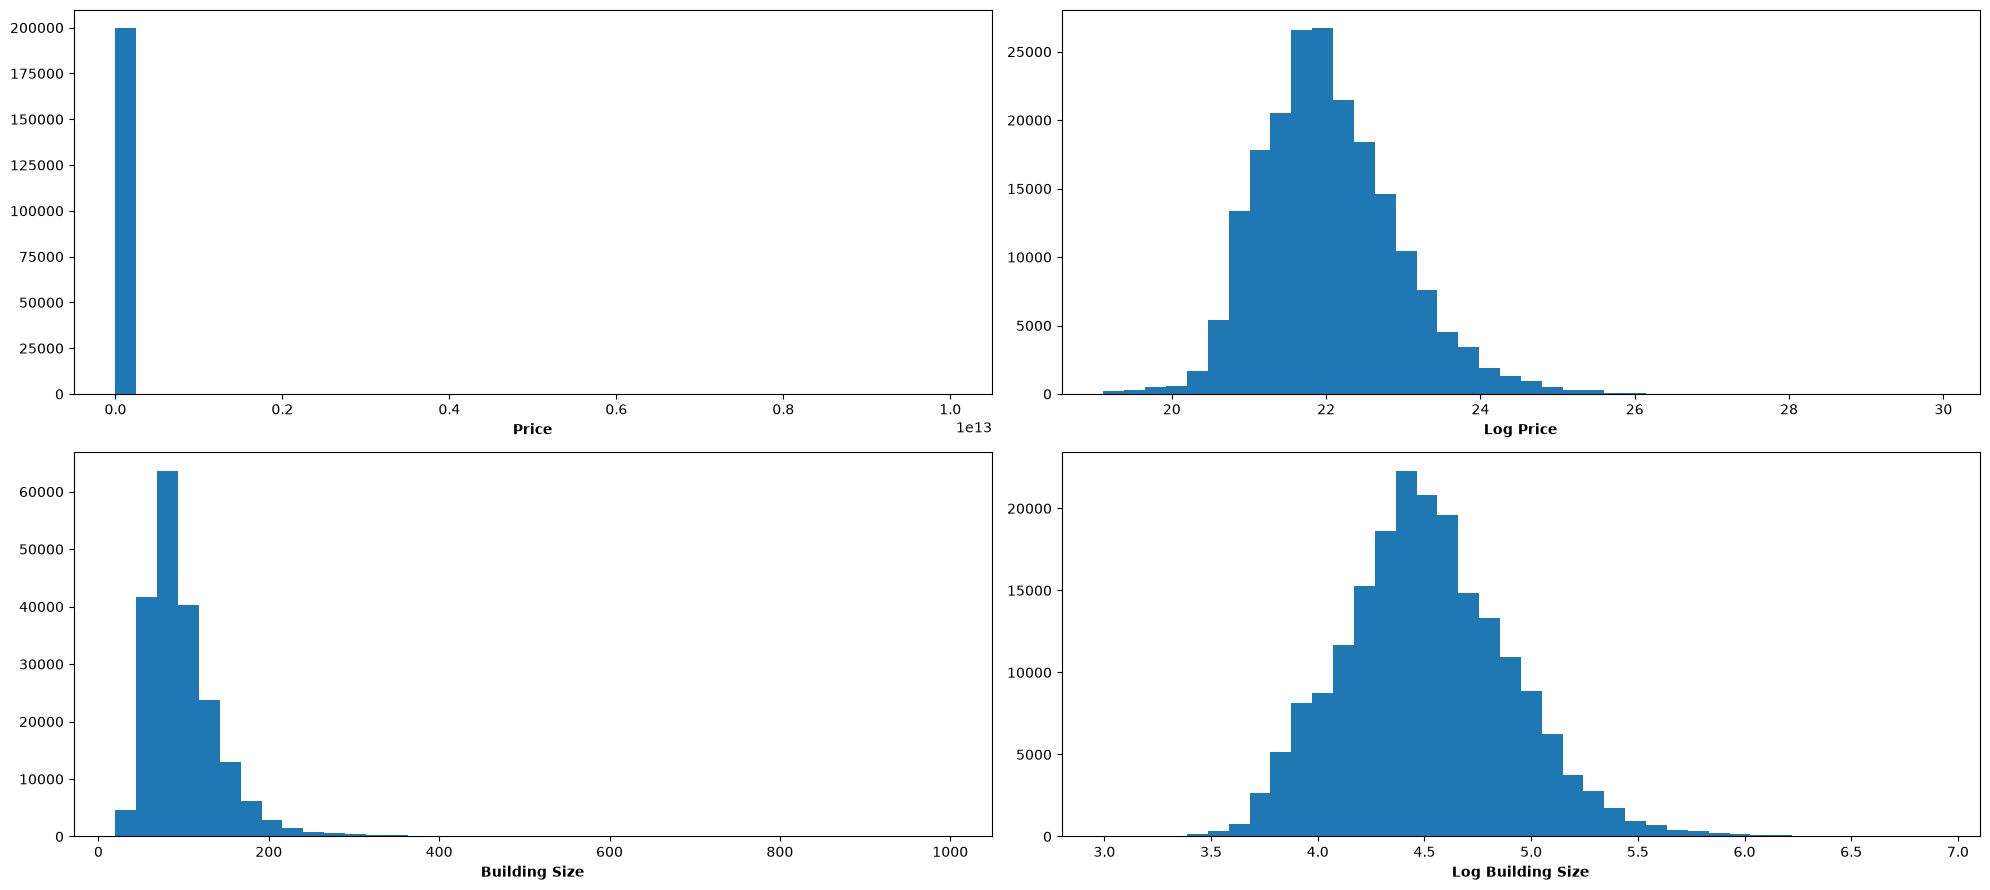

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 9))
axes[0, 0].hist(iran_apartments_clean["price_value"], bins=40)
axes[0, 0].set_xlabel("Price", fontweight="bold")

axes[0, 1].hist(iran_apartments_clean["log_price"], bins=40)
axes[0, 1].set_xlabel("Log Price", fontweight="bold")

axes[1, 0].hist(iran_apartments_clean["building_size"], bins=40)
axes[1, 0].set_xlabel("Building Size", fontweight="bold")

axes[1, 1].hist(iran_apartments_clean["log_building_size"], bins=40)
axes[1, 1].set_xlabel("Log Building Size", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
print("price_value:", iran_apartments_clean["price_value"].skew().round(3))
print("log_price:", iran_apartments_clean["log_price"].skew().round(3))
print("building_size:", iran_apartments_clean["building_size"].skew().round(3))
print("log_building_size:", iran_apartments_clean["log_building_size"].skew().round(3))

price_value: 46.732
log_price: 0.908
building_size: 4.539
log_building_size: 0.476


-----------

UTM

In [20]:
import geopandas as gpd
iran_border = gpd.read_file("https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IRN_0.json").to_crs("EPSG:32639")
iran_points = gpd.GeoSeries(gpd.points_from_xy(
        iran_apartments_clean["location_longitude"],
        iran_apartments_clean["location_latitude"]
    ), index=iran_apartments_clean.index, crs="EPSG:4326").to_crs("EPSG:32639")
iran_area = iran_border.geometry.union_all().buffer(5000)
valid_iran_location = iran_points.within(iran_area)
print("Invalid locations:", (~valid_iran_location).sum())
iran_apartments_clean = iran_apartments_clean.loc[valid_iran_location].copy()

Invalid locations: 230


بعد از مشخص کردن رنج لت و لانگ ایران و بعد از انجام تسک اول متوجه شدم بعضی نقاط اشتباه تو نقشه پدیدار شدن و جزو مرز ایران نیست

بعضی نقاط جزو کشور های همسایه و بعضی نقاط تو دریای خزر بودن برای همین بعد از سرچ متوجه شدم رنج مشخص کردن برای لت و لانگ نقشرو به صورت مستطیلی در نظر میگیره و به همین علت اوت لایر داریم

برای همین از ژیو پانداز استفاده کردم و برای جلوگیری از حذف نقاط ساحلی و معتبر حاشیه 5 کیلومتری در نظر گرفتم که تا 5 کیلومتر ولید باشن و حذف نشن

In [21]:
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
utm_easting, utm_northing = transformer.transform(
    iran_apartments_clean["location_longitude"].to_numpy(),
    iran_apartments_clean["location_latitude"].to_numpy())
iran_apartments_clean["utm_easting"] = utm_easting
iran_apartments_clean["utm_northing"] = utm_northing

---------

In [22]:
iran_apartments_clean["building_age"] = 1405 - iran_apartments_clean["construction_year_numeric"]

In [23]:
k_means_feature = [
    "log_price",
    "log_building_size",
    "rooms_count_numeric",
    "building_age",
    "utm_easting",
    "utm_northing"
]
model_rows = iran_apartments_clean[k_means_feature].notna().all(axis=1)
iran_model_data = iran_apartments_clean.loc[model_rows].copy()

-----------

test best feature sets for K-means

In [25]:
feature_test_1 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "log_building_size"
]
feature_test_2 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "rooms_count_numeric"
]
feature_test_3 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "building_age"
]
feature_test_4 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "log_building_size",
    "rooms_count_numeric"
]
feature_test_5 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "log_building_size",
    "building_age"
]
feature_test_6 = [
    "log_price",
    "utm_easting",
    "utm_northing",
    "rooms_count_numeric",
    "building_age"
]
all_feature_tests = {
    "feature_test_1": feature_test_1,
    "feature_test_2": feature_test_2,
    "feature_test_3": feature_test_3,
    "feature_test_4": feature_test_4,
    "feature_test_5": feature_test_5,
    "feature_test_6": feature_test_6
}

In [26]:
scaled_tests = {}
scale = {}
for key, value in all_feature_tests.items():
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(iran_model_data[value])
    scaled_tests[key] = scaled_data
    scale[key] = scaler

In [27]:
silhouette_scores = {}
for key, value in scaled_tests.items():
    k_means = KMeans(n_clusters=10, n_init=10, random_state=42)
    labels = k_means.fit_predict(value)
    silhouette_scores[key] = silhouette_score(value, labels, sample_size=100000, random_state=42)

In [28]:
silhouette_scores = pd.Series(silhouette_scores)
silhouette_scores

feature_test_1    0.288887
feature_test_2    0.395759
feature_test_3    0.283209
feature_test_4    0.348695
feature_test_5    0.237969
feature_test_6    0.268299
dtype: float64

In [29]:
best_test_name = silhouette_scores.idxmax()
best_features = all_feature_tests[best_test_name]
best_features

['log_price', 'utm_easting', 'utm_northing', 'rooms_count_numeric']

End of pre processing 

-----

----

-----

Part 1

In [30]:
final__K_means = KMeans(n_clusters=10, n_init=20, random_state=42)
final_labels = final__K_means.fit_predict(scaled_tests[best_test_name])

In [31]:
iran_model_data["cluster"] = final_labels
iran_model_data["cluster"].value_counts()

cluster
0    43933
4    36381
7    34737
2    15718
3    15302
8    14449
9    12967
6    10464
1     9386
5     6298
Name: count, dtype: int64

In [32]:
cluster_centers = scale[best_test_name].inverse_transform(final__K_means.cluster_centers_)
cluster_centers = pd.DataFrame(cluster_centers, columns=best_features)
cluster_centers["price_value"] = np.exp(cluster_centers["log_price"])
cluster_centers["price_billion"] = cluster_centers["price_value"] / 1000000000
cluster_centers["cluster"] = range(10)
cluster_centers[[
    "cluster",
    "price_billion",
    "utm_easting",
    "utm_northing",
    "rooms_count_numeric"
]]

,cluster,price_billion,utm_easting,utm_northing,rooms_count_numeric
0,0,2.103176,5.264130e+05,3.958440e+06,2.010395
1,1,3.284678,8.492416e+05,3.216036e+06,1.943213
2,2,6.643761,4.181634e+05,3.992889e+06,3.032992
3,3,2.981194,1.249154e+06,4.051660e+06,2.156712
4,4,2.137503,5.120979e+05,3.942466e+06,0.988126
5,5,7.401336,5.354196e+05,3.463361e+06,3.072086
6,6,31.619226,5.428868e+05,3.957374e+06,3.104785
7,7,7.851850,5.256544e+05,3.956354e+06,1.976776
8,8,2.598176,3.779110e+05,3.634335e+06,1.988790
9,9,2.414129,1.964402e+05,4.170955e+06,1.887324


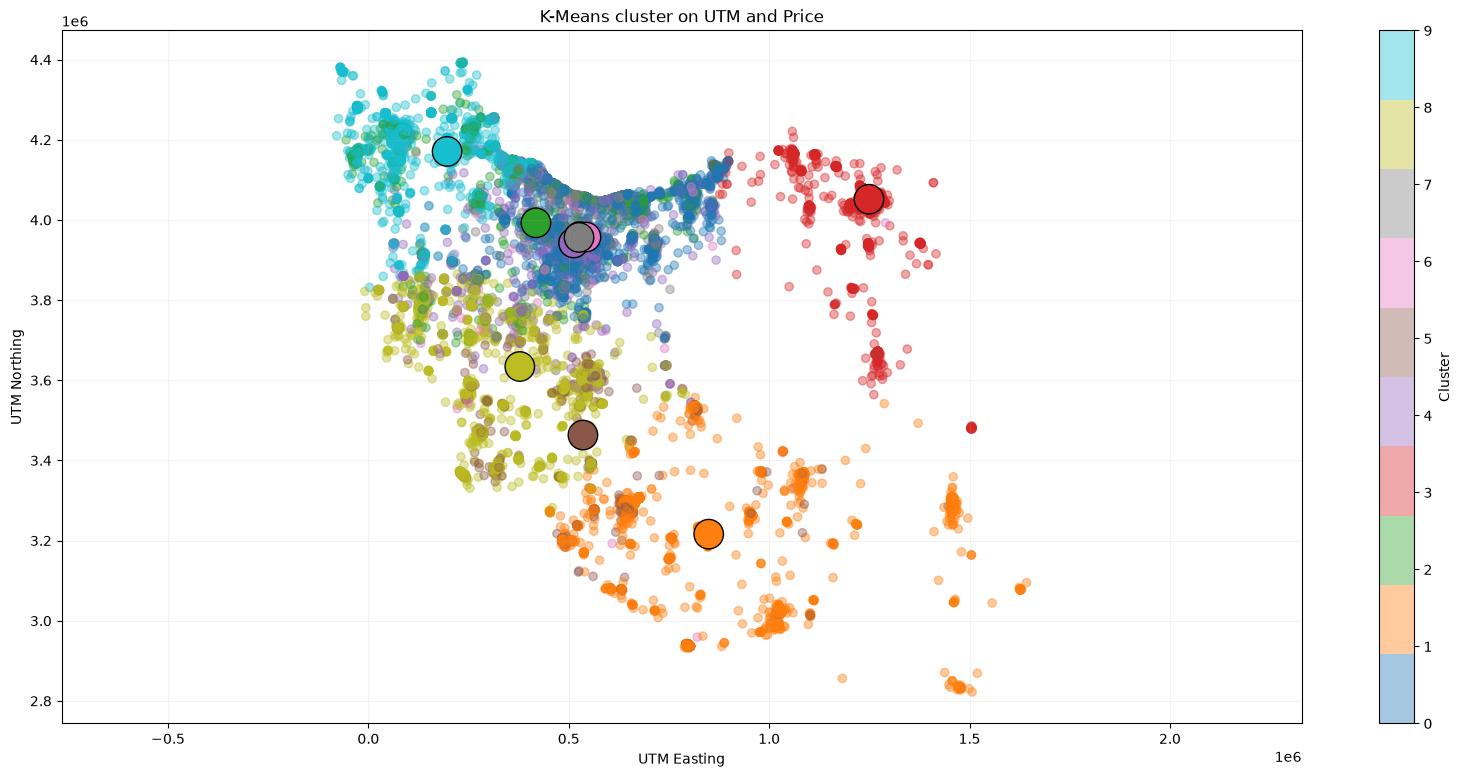

In [33]:
plt.figure(figsize=(20, 9))
scatter = plt.scatter(iran_model_data["utm_easting"], iran_model_data["utm_northing"], c=iran_model_data["cluster"], cmap="tab10", alpha=0.4)
plt.scatter(cluster_centers["utm_easting"], cluster_centers["utm_northing"], c=cluster_centers["cluster"], cmap="tab10", s=450, edgecolor="black")
colorbar = plt.colorbar(scatter, ticks=range(10))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("K-Means cluster on UTM and Price")
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

In [34]:
cluster_report = (iran_model_data.groupby("cluster").agg(
    ads_count = ("cluster", "count"),
    min_price = ("price_value", "min"),
    median_price = ("price_value", "median"),
    max_price = ("price_value", "max"),
    min_building_size = ("building_size", "min"),
    median_building_size = ("building_size", "median"),
    max_building_size = ("building_size", "max"),
    min_rooms = ("rooms_count_numeric", "min"),
    median_rooms = ("rooms_count_numeric", "median"),
    max_rooms = ("rooms_count_numeric", "max"),
    city = ("city_slug", lambda x: x.mode().iloc[0])
))
cluster_report["median_price_billion"] = cluster_report["median_price"] / 1000000000
cluster_report["min_price_billion"] = cluster_report["min_price"] / 1000000000
cluster_report["max_price_billion"] = cluster_report["max_price"] / 1000000000

In [35]:
cluster_report[[
    "ads_count",
    "min_price_billion",
    "median_price_billion",
    "max_price_billion",
    "min_building_size",
    "median_building_size",
    "max_building_size",
    "min_rooms",
    "median_rooms",
    "max_rooms",
    "city"
]]

,ads_count,min_price_billion,median_price_billion,max_price_billion,min_building_size,median_building_size,max_building_size,min_rooms,median_rooms,max_rooms,city
cluster,,,,,,,,,,,
0,43933,0.20,2.30,4.080000,30.0,85.0,1000.0,2.0,2.0,4.0,karaj
1,9386,0.20,3.25,165.000000,24.0,100.0,800.0,0.0,2.0,4.0,shiraz
2,15718,0.20,6.70,25.000000,25.0,145.0,1000.0,3.0,3.0,5.0,tehran
3,15302,0.20,3.10,47.900000,30.0,100.0,700.0,0.0,2.0,5.0,mashhad
4,36381,0.20,2.11,33.825000,20.0,55.0,1000.0,0.0,1.0,1.0,tehran
5,6298,0.50,7.00,111.111111,35.0,151.0,1000.0,2.0,3.0,5.0,isfahan
6,10464,7.89,26.00,10000.000000,36.0,165.0,1000.0,1.0,3.0,5.0,tehran
7,34737,4.05,7.45,156.000000,33.0,95.0,1000.0,0.0,2.0,2.0,tehran
8,14449,0.20,2.70,15.000000,20.0,94.0,955.0,1.0,2.0,3.0,isfahan


نتایج نشون میده خوشه‌ ها علاوه بر موقعیت جغرافیایی، از نظر قیمت و ویژگی‌ ها نیز تفاوت دارن

مثلا خوشه ۲ بیشتر شامل آپارتمان‌ های گران‌ تر، بزرگ‌تر و سه‌ خوابه با تمرکز در تهران هست

اما خوشه ۳ بیشتر شامل آپارتمان های کوچیک تر، ارزان‌ تر و یک‌ خوابه هست

همچنین خوشه‌های ۰ و ۱ با وجود میانه قیمت مشابه، از نظر شهر غالب و متراژ باهم تفاوت دارن

این موضوع نشون میده که مدل فقط بر اساس قیمت تصمیم نگرفته و موقعیت جغرافیایی و تعداد اتاق هم در تشکیل خوشه‌ ها موثر بوده‌

بخاطر حساسیت مقادیر کمینه و بیشینه به داده‌ های پرت و انتهایی، برای تفسیر خوشه‌ ها بیشتر از میانه استفاده می‌کنیم

----------

Part 2

In [36]:
k_range = range(1, 21)
wcss_scores = []
silhouette_scores_k = []
davies_scores = []
calinski_scores = []

for i in k_range:
    k_means = KMeans(n_clusters=i, n_init=10, random_state=42)
    labels = k_means.fit_predict(scaled_tests[best_test_name])
    wcss_scores.append(k_means.inertia_)
    if i > 1:
        silhouette_scores_k.append(silhouette_score(scaled_tests[best_test_name], labels, sample_size=10000, random_state=42))
        davies_scores.append(davies_bouldin_score(scaled_tests[best_test_name], labels))
        calinski_scores.append(calinski_harabasz_score(scaled_tests[best_test_name], labels))

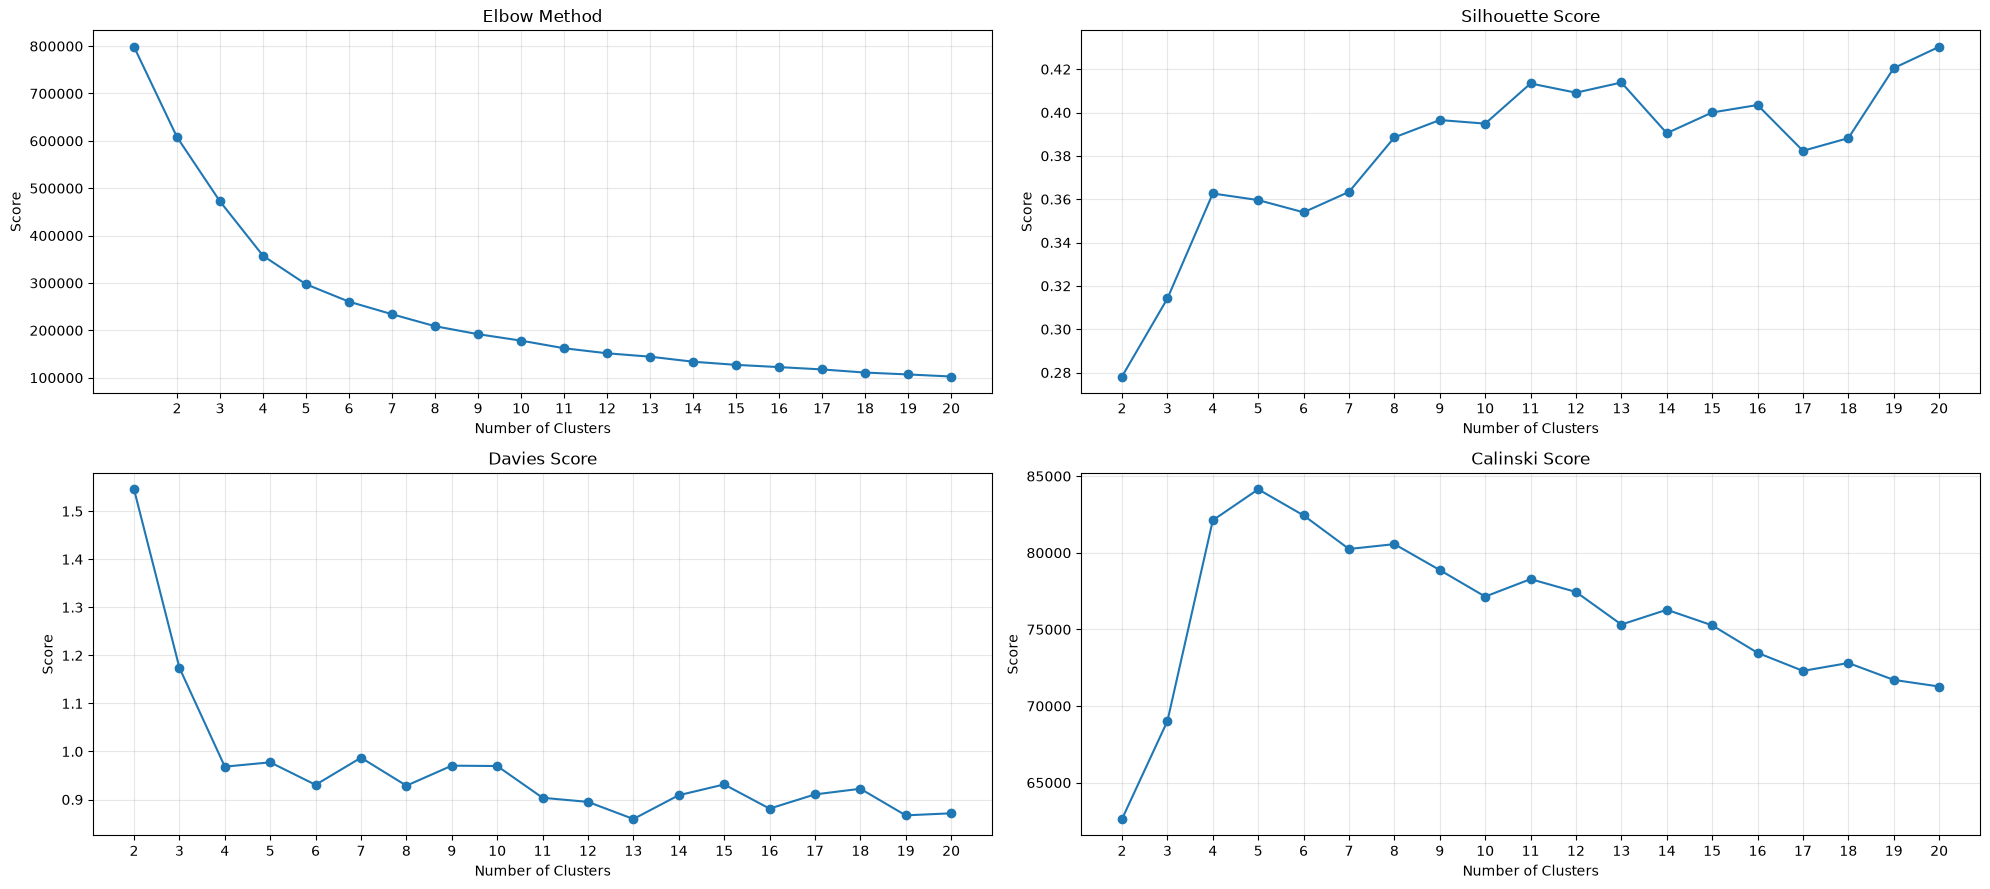

In [37]:
k_range_plot = range(2, 21, 1)
fig, axes = plt.subplots(2, 2, figsize=(20, 9))
axes[0, 0].plot(k_range, wcss_scores, marker="o")
axes[0, 0].set_title("Elbow Method")

axes[0, 1].plot(k_range_plot, silhouette_scores_k, marker="o")
axes[0, 1].set_title("Silhouette Score")

axes[1, 0].plot(k_range_plot, davies_scores, marker="o")
axes[1, 0].set_title("Davies Score")

axes[1, 1].plot(k_range_plot, calinski_scores, marker="o")
axes[1, 1].set_title("Calinski Score")
for i in axes.flat:
    i.grid(alpha=0.3)
    i.set_xlabel("Number of Clusters")
    i.set_ylabel("Score")
    i.set_xticks(range(2, 21, 1))
plt.tight_layout()
plt.show()

بعد برای انتخاب کا
توی معیار البو اون شکستگی رو هم کای 4 و هم کای 5 میشه حساب گرد

توی معیار سلیهوعت اسکور بهتر برای کا = 4  هست و برای کا = 5 حدود 0.03 افت داشته

توی معیار داویس که اسکور کمتر بهتره، باز کا = 4 اسکور بهتری نسبت به کا = 5 داره 

توی معیار کالینسکی بهترین اسکور برای کا = 5 هست

در مجموع با اینکه معیار کالینسکی مفدار کا = 5 رو بهتر میدونه اما معیار های داویس و سیلهوعت در کا = 4 نتیجه بهتری دارن و پلات ابو نیز این مفدار رو تایید میکنه

در نتیجه با در نظر گرفتن کیفیت جدا سازی خوشه، سادگی مدل و تعداد خوشه ها کا = 4 به عنوان مدل نهایی انتخاب شد


In [38]:
best_k = 4
best_k_means = KMeans(n_clusters=best_k, n_init=20, random_state=42)
best_k_labels = best_k_means.fit_predict(scaled_tests[best_test_name])

Part 3

In [24]:
from sklearn.cluster import DBSCAN
dbscan_features = [
    "price_value",
    "utm_easting",
    "utm_northing"
]
dbscan_scaler = StandardScaler()
dbscan_data = dbscan_scaler.fit_transform(iran_model_data[dbscan_features])

In [25]:
dbscan_sample = iran_model_data.sample(n=100000, random_state=42).copy()
dbscan_features = [
    "price_value",
    "utm_easting",
    "utm_northing"
]
dbscan_scaler = StandardScaler()
dbscan_data = dbscan_scaler.fit_transform(dbscan_sample[dbscan_features])

Test 1
----

In [26]:
test_1 = DBSCAN(eps=0.3, min_samples=10, n_jobs=-1)
test_1_labels = test_1.fit_predict(dbscan_data)
dbscan_sample["dbscan_test_1"] = test_1_labels
dbscan_sample["dbscan_test_1"].value_counts().sort_index()

dbscan_test_1
-1       185
 0     89538
 1      7641
 2       331
 3       923
 4       326
 5       554
 6       239
 7        12
 8        49
 9       132
 10       47
 11       20
 12        3
Name: count, dtype: int64

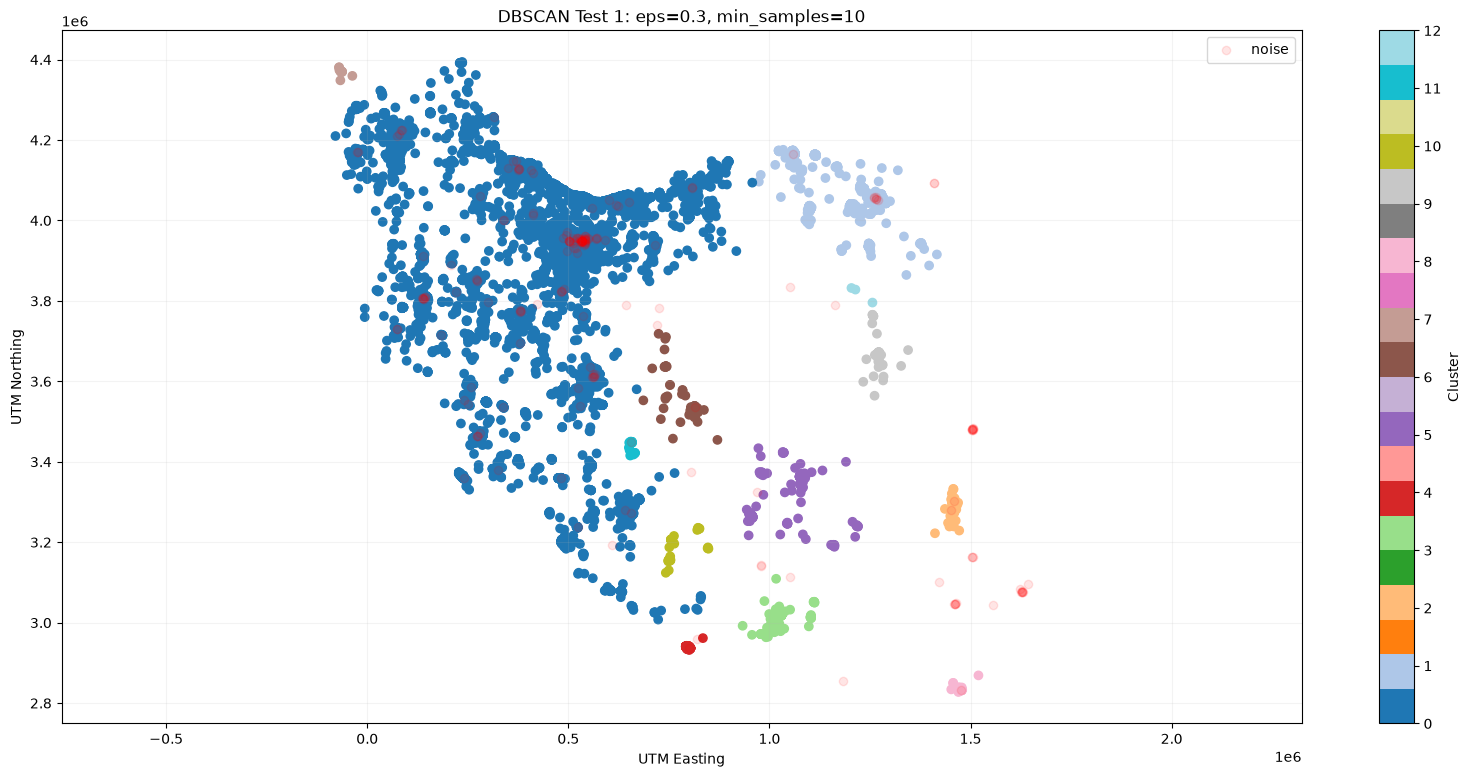

In [27]:
normal = (dbscan_sample["dbscan_test_1"] != -1)
noise = (dbscan_sample["dbscan_test_1"] == -1)
plt.figure(figsize=(20, 9))
scatter = plt.scatter(dbscan_sample.loc[normal, "utm_easting"], dbscan_sample.loc[normal, "utm_northing"], c=dbscan_sample.loc[normal, "dbscan_test_1"], cmap="tab20")
plt.scatter(dbscan_sample.loc[noise, "utm_easting"], dbscan_sample.loc[noise, "utm_northing"], color="red", alpha=0.1, label="noise")
colorbar = plt.colorbar(scatter, ticks=range(13))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Test 1: eps=0.3, min_samples=10")
plt.legend()
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

Test 2
----

In [28]:
test_2 = DBSCAN(eps=0.7, min_samples=10, n_jobs=-1)
test_2_labels = test_2.fit_predict(dbscan_data)
dbscan_sample["dbscan_test_2"] = test_2_labels
dbscan_sample["dbscan_test_2"].value_counts().sort_index()

dbscan_test_2
-1       98
 0    99495
 1      358
 2       49
Name: count, dtype: int64

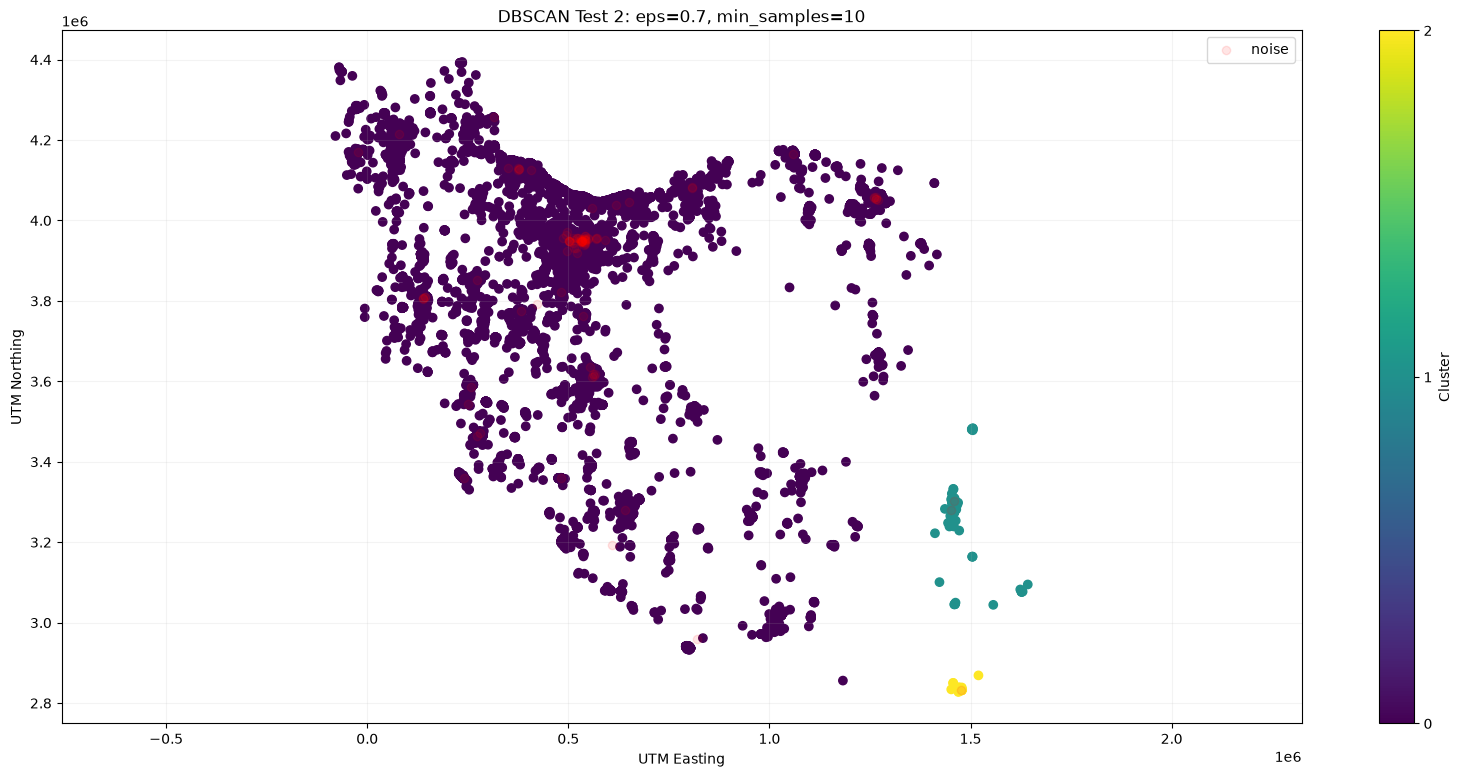

In [29]:
normal = (dbscan_sample["dbscan_test_2"] != -1)
noise = (dbscan_sample["dbscan_test_2"] == -1)
plt.figure(figsize=(20, 9))
scatter = plt.scatter(dbscan_sample.loc[normal, "utm_easting"], dbscan_sample.loc[normal, "utm_northing"], c=dbscan_sample.loc[normal, "dbscan_test_2"])
plt.scatter(dbscan_sample.loc[noise, "utm_easting"], dbscan_sample.loc[noise, "utm_northing"], color="red", alpha=0.1, label="noise")
colorbar = plt.colorbar(scatter, ticks=range(3))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Test 2: eps=0.7, min_samples=10")
plt.legend()
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

Test 3
----

In [50]:
test_3 = DBSCAN(eps=0.55, min_samples=500, n_jobs=-1)
test_3_labels = test_3.fit_predict(dbscan_data)
dbscan_sample["dbscan_test_3"] = test_3_labels
dbscan_sample["dbscan_test_3"].value_counts().sort_index()

dbscan_test_3
-1     1028
 0    97493
 1      945
 2      534
Name: count, dtype: int64

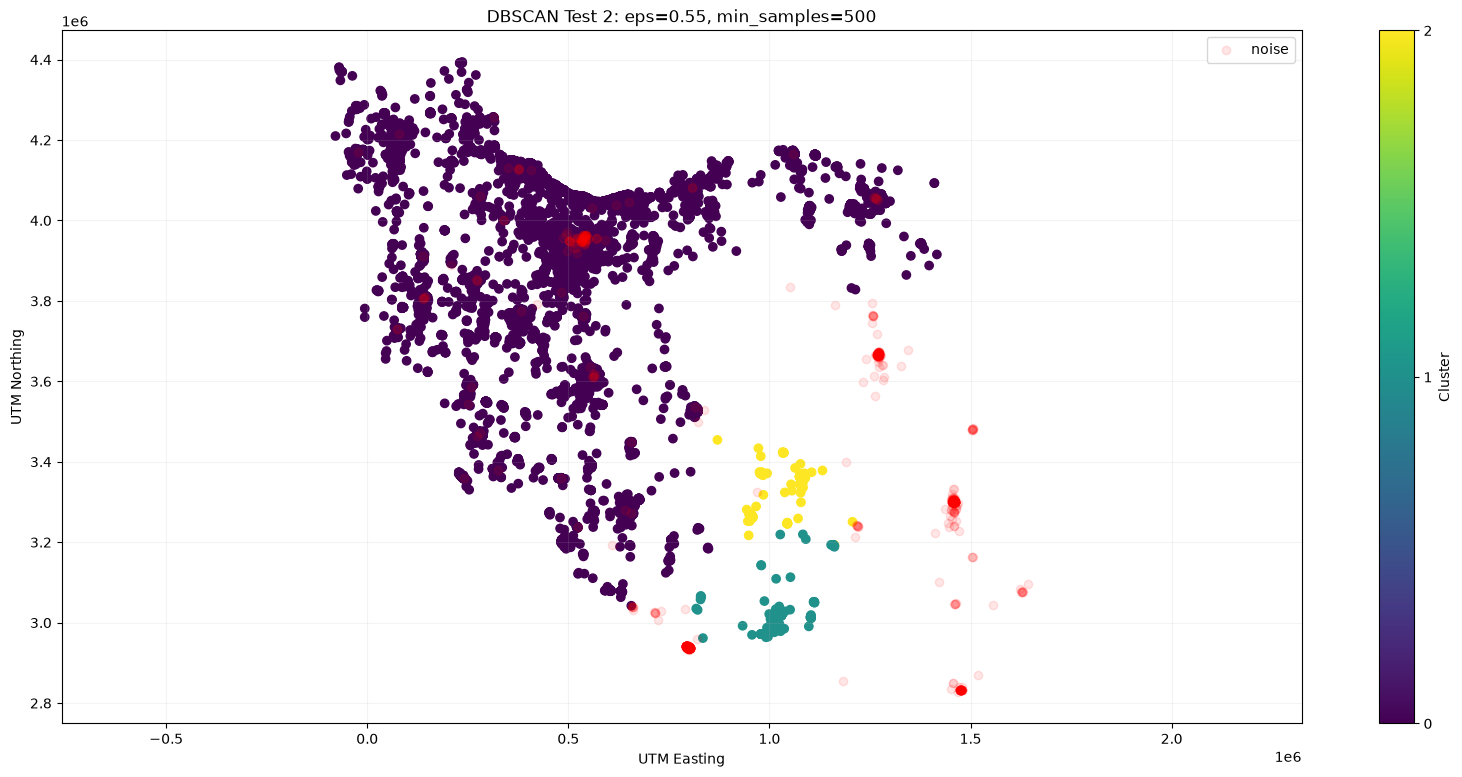

In [51]:
normal = (dbscan_sample["dbscan_test_3"] != -1)
noise = (dbscan_sample["dbscan_test_3"] == -1)
plt.figure(figsize=(20, 9))
scatter = plt.scatter(dbscan_sample.loc[normal, "utm_easting"], dbscan_sample.loc[normal, "utm_northing"], c=dbscan_sample.loc[normal, "dbscan_test_3"])
plt.scatter(dbscan_sample.loc[noise, "utm_easting"], dbscan_sample.loc[noise, "utm_northing"], color="red", alpha=0.1, label="noise")
colorbar = plt.colorbar(scatter, ticks=range(4))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Test 2: eps=0.55, min_samples=500")
plt.legend()
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

Test 4
----

In [52]:
test_4 = DBSCAN(eps=0.55, min_samples=1000, n_jobs=-1)
test_4_labels = test_4.fit_predict(dbscan_data)
dbscan_sample["dbscan_test_4"] = test_4_labels
dbscan_sample["dbscan_test_4"].value_counts().sort_index()

dbscan_test_4
-1     2518
 0    89849
 1     7633
Name: count, dtype: int64

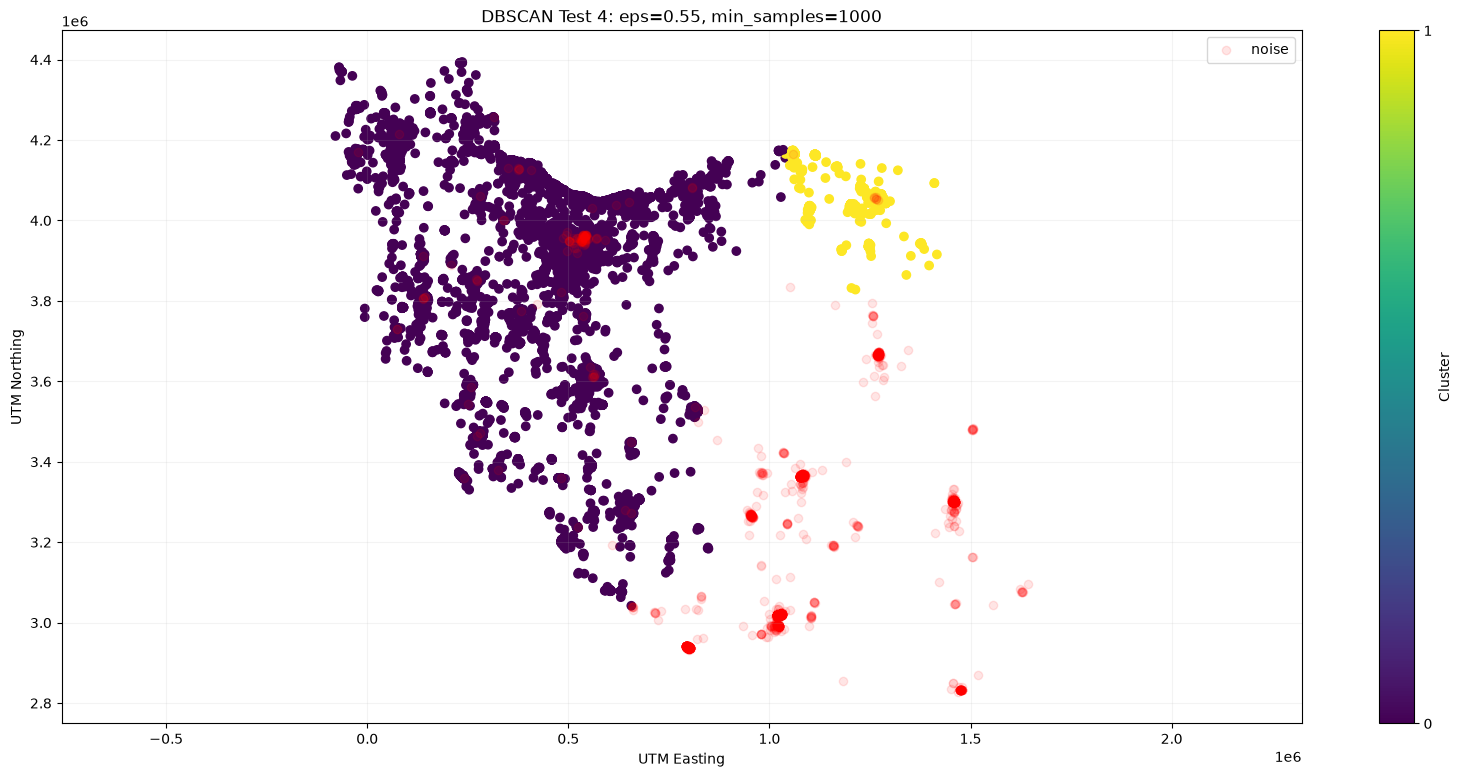

In [53]:
normal = (dbscan_sample["dbscan_test_4"] != -1)
noise = (dbscan_sample["dbscan_test_4"] == -1)
plt.figure(figsize=(20, 9))
scatter = plt.scatter(dbscan_sample.loc[normal, "utm_easting"], dbscan_sample.loc[normal, "utm_northing"], c=dbscan_sample.loc[normal, "dbscan_test_4"])
plt.scatter(dbscan_sample.loc[noise, "utm_easting"], dbscan_sample.loc[noise, "utm_northing"], color="red", alpha=0.1, label="noise")
colorbar = plt.colorbar(scatter, ticks=range(3))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Test 4: eps=0.55, min_samples=1000")
plt.legend()
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

-----

1. شروع با اپسیلون 0.3 و حداقل تعداد نقاط برای خوشه بندی 10، نتیجه : شعاع کوچیک بود و تقریبا 20 خوشه و 683 نویز تشکیل شد
---
2. آزمایش با اپسیلون 0.7 و حداقل تعداد نقاط برای خوشه بندی 10، نتیجه: 3 خوشه و 106 نویز اما 99 درصد دیتا ها در یه خوشه قرار گرفتن
---
3. آزمایش با اپسیلون 0.4 و حداقل تعداد نقاط برای خوشه بندی 10، نتیجه: 10 خوشه و 341 نویز اما مجدد بیشتر دیتا تو یه خوشه قرار گرفتن
---
4.  آزمایش با اپسیلون 0.4 و حداقل تعداد نقاط برای خوشه بندی 100، نتیجه: 8 خوشه و 2034 نویز و باز هم تعداد زیادی از دیتا تو یک خوشه قرار گرفت
---
5. آزمایش با اپسیلون 0.4 و حداقل تعداد نقاط برای خوشه بندی 500، نتیجه: 6 خوشه و 8154 نویز ولی افزایش سمپل باعث حذف خوشه های بسیار کوچک و ایجاد خوشه های معنادار تری شد
---
6. آزمایش با اپسیلون 0.45 و حداقل تعداد نقاط برای خوشه بندی 500، نتیجه: 6 خوشه و 6087 نویز پش افزایش اپسیلون باعث کاهش نویز شد
---
7. آزمایش با اپسیلون 0.5 و حداقل تعداد نقاط برای خوشه بندی 500، نتیجه: 5 خوشه و 4543 نویز پس افزایش اپسیلون باعث ادغام یکی از خوشه ها و کاهش نقاط نویز شد
---
8. آزمایش با اپسیلون 0.55 و حداقل تعداد نقاط برای خوشه بندی 500، نتیجه: 4 خوشه و 3824 نویز پس افزایش اپسیلون باعث ادغام یکی دیگه از خوشه ها و کاهش نقاط نویز شد
---
9. آزمایش با اپسیلون 0.6 و حداقل تعداد نقاط برای خوشه بندی 500، نتیجه: 4 خوشه و 2601 نویز پس افزایش اپسیلون باعث کاهش نقاط نویز شد ولی حدود 97 درصد دیتا ها مجدد متعلق به یه خوشه هستن و این  تنظیم خوبی نبود
---
10.  آزمایش با اپسیلون 0.55 و حداقل تعداد نقاط برای خوشه بندی 1000، نتیجه: 4 خوشه و 6076 نویز و افزایش سمپل باعث باعث جلوگیری از ادغام داده ها شد و  خوشه ها مقدار بزرگ تری گرفتند
---
11.  آزمایش با اپسیلون 0.55 و حداقل تعداد نقاط برای خوشه بندی 1500، نتیجه: 3 خوشه و 9244 نویز پس افزایش سمپل باعث شد خوشه کوچک قبلی حذف و سه ناحیه متراکن باقی بمونن
---
12.  آزمایش با اپسیلون 0.54 و حداقل تعداد نقاط برای خوشه بندی 1500، نتیجه: 3 خوشه و 9830 نویز و امتیاز سیلهوعت 0.5046 و میزان نویز افزایش داشت
---
13.  آزمایش با اپسیلون 0.56 و حداقل تعداد نقاط برای خوشه بندی 1500، نتیجه: 3 خوشه و 8815 نویز و امتیاز سیلهوعت 0.5091، بالاترین امتیاز سیلهوعت و کاهش نویز
---
14.  آزمایش با اپسیلون 0.55 و حداقل تعداد نقاط برای خوشه بندی 1250، نتیجه: 3 خوشه و 8290 نویز و امتیاز سیلهوعت 0.507، نویز و سیلهوعت هردو کاهش
---
15.  آزمایش با اپسیلون 0.55 و حداقل تعداد نقاط برای خوشه بندی 1750، نتیجه: 4 خوشه و 10527 نویز و مورد مناسبی نبود
---
16.  آزمایش با اپسیلون 0.58 و حداقل تعداد نقاط برای خوشه بندی 1500، نتیجه: 3 خوشه و 8056 نویز و امتیاز سیلهوعت 0.507، با اینکه کاهش نویز داشتیم ولی خوشه اصلی نامتوازن تر شد و افزایش دیتا داشت
---
*مدل نهایی : 13*

-----

Final-Model
----

In [34]:
dbscan_model = DBSCAN(eps=0.56, min_samples=1500, n_jobs=-1)
dbscan_labels = dbscan_model.fit_predict(dbscan_data)
dbscan_sample["dbscan_cluster"] = dbscan_labels
dbscan_sample["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     2524
 0    86443
 1     3390
 2     7643
Name: count, dtype: int64

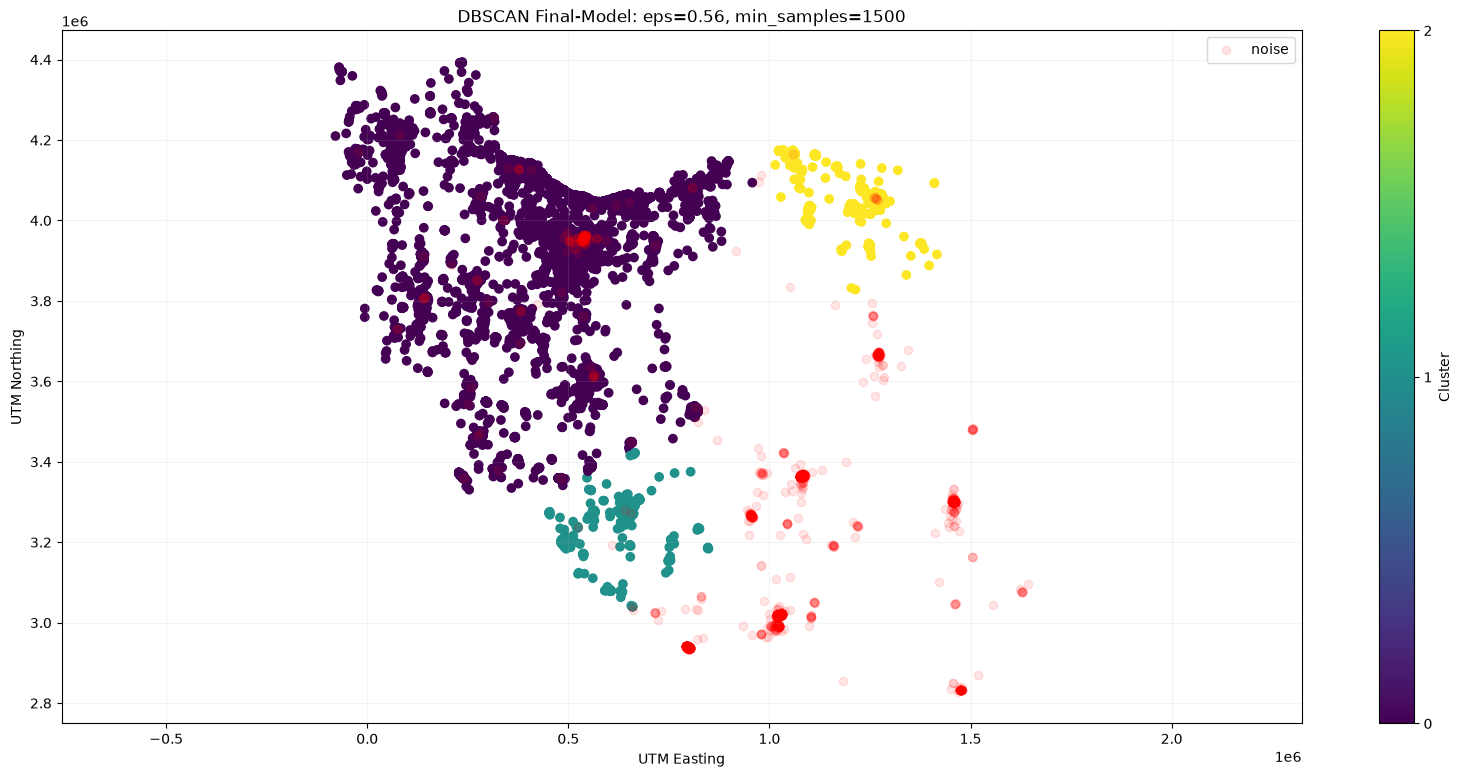

2026-10-02 12:05:22,949 - INFO     - Executing shutdown due to inactivity...
2026-10-02 12:05:23,060 - INFO     - Executing shutdown...
2026-10-02 12:05:23,062 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer


In [ ]:
normal = (dbscan_sample["dbscan_cluster"] != -1)
noise = (dbscan_sample["dbscan_cluster"] == -1)
plt.figure(figsize=(20, 9))
scatter = plt.scatter(dbscan_sample.loc[normal, "utm_easting"], dbscan_sample.loc[normal, "utm_northing"], c=dbscan_sample.loc[normal, "dbscan_cluster"])
plt.scatter(dbscan_sample.loc[noise, "utm_easting"], dbscan_sample.loc[noise, "utm_northing"], color="red", alpha=0.1, label="noise")
colorbar = plt.colorbar(scatter, ticks=range(3))
colorbar.set_label("Cluster")
plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Final-Model: eps=0.56, min_samples=1500")
plt.legend()
plt.grid(alpha=0.15)
plt.axis("equal")
plt.show()

نقاط قرمز رنگ با برچسب منفی 1 به عنئان نقاط نویز محسوب میشن و این نقاط بیشتر در مناطق جفرافیایی کم تراکم قرار داشتند و حدود 4.5 درصد کل دیتارو تشکیل دادن
***
پارامتر اپسیلون مشخص کننده شعاع همسایگی نقاطه و همونجور که توی نتایج ذکر شد افزایش این پارامتر با اینکه نویز رو خیلی کم میکنه اما باعث اتصال نواحی مختلف و تشکیل یه خوشه بسیار بزرگ میشد در حالی که کاهش این پارامتر مقدار زیادی خوشه کوچک تولید کرد
***
دی بی اسکن بر خلاف کا مینز تمام دیتا رو مجبور به عضویت در یگ خوشه نمیکنه و به عنوان نویز میتونه بعضی نقاط رو شناسایی کنه

و بخاطر استفاده از یک اپسیلون ثابت برای کل ایران به دلیل اینکه تراکن آگهی تو دیتامون به صورت مساوی نیست بخاطر همین باعث تشکیل خوشه غالب شد
***

In [54]:
models = [
    ("Test 1", 0.30, 10, test_1_labels),
    ("Test 2", 0.70, 10, test_2_labels),
    ("Test 3", 0.50, 500, test_3_labels),
    ("Test 4", 0.50, 1000, test_4_labels),
    ("Final Model", 0.56, 1500, dbscan_labels)
]
res = []
for name, eps, min_samples, labels in models:
    labels = np.asarray(labels)
    noise = (labels == -1)
    normal = (labels != -1)
    noise_count = noise.sum()
    noise_percent = (noise_count / len(labels)) * 100
    cluster_sizes = pd.Series(labels[normal]).value_counts()
    cluster_count = len(cluster_sizes)
    largest_cluster_percent = (cluster_sizes.max() / normal.sum()) * 100
    if cluster_count > 1:
        silhouette = silhouette_score(dbscan_data[normal], labels[normal], sample_size=10000, random_state=42)
    else:
        silhouette = np.nan
    res.append({
        "Model": name,
        "eps": eps,
        "min_samples": min_samples,
        "Cluster": cluster_count,
        "Noise count": noise_count,
        "Noise percent": noise_percent,
        "Largest Cluster percent": largest_cluster_percent,
        "Silhouette": silhouette
    })
res_table = pd.DataFrame(res)
res_table

,Model,eps,min_samples,Cluster,Noise count,Noise percent,Largest Cluster percent,Silhouette
0,Test 1,0.30,10,13,185,0.185,89.703952,0.480307
1,Test 2,0.70,10,3,98,0.098,99.592601,0.661245
2,Test 3,0.50,500,3,1028,1.028,98.505638,0.590724
3,Test 4,0.50,1000,2,2518,2.518,92.169836,0.702777
4,Final Model,0.56,1500,3,2524,2.524,88.681316,0.691524


In [48]:
dbscan_report = dbscan_sample.groupby("dbscan_cluster").agg(
    ads_count = ("dbscan_cluster", "count"),
    median_price_billion = ("price_value", "median"),
    median_building_size=("building_size", "median"),
    median_rooms=("rooms_count_numeric", "median"),
    city = ("city_slug", lambda x: x.mode().iloc[0])
)

In [49]:
dbscan_report["median_price_billion"] = dbscan_report["median_price_billion"] / 1000000000
dbscan_report

,ads_count,median_price_billion,median_building_size,median_rooms,city
dbscan_cluster,,,,,
-1,2524,3.20,95.0,2.0,bandar-abbas
0,86443,3.35,87.0,2.0,tehran
1,3390,4.30,120.0,2.0,shiraz
2,7643,3.15,100.0,2.0,mashhad
